Import the white wines as the dataset

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# dataframe
df = pd.read_csv("winequality-white.csv", delimiter=";")

Verify which correlation is highest for the density of the wine

<Axes: >

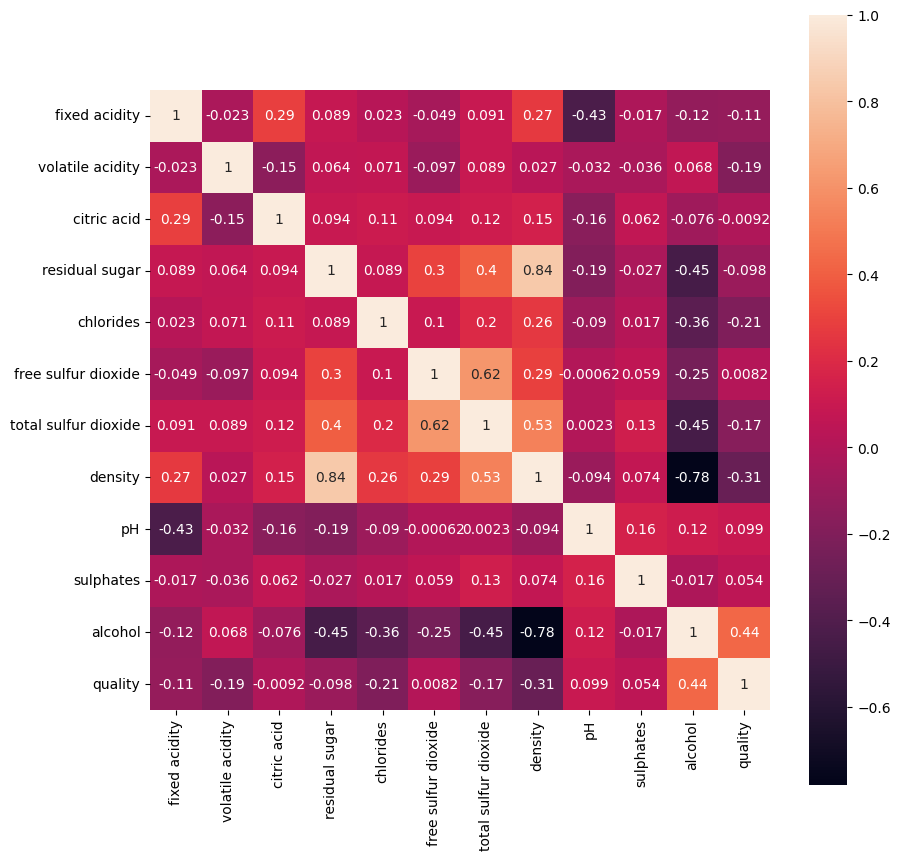

In [15]:
correlation = df.corr(method='pearson')

fig = plt.gcf()

fig.set_size_inches(10,10)

sns.heatmap(correlation, annot = True,square = True)

It seems to be **residual sugar** with **0.84 correlation**. We build the model based on that.

In [43]:
from sklearn.model_selection import train_test_split

X = df[['residual sugar'] ]
y = df['density']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)

Scale the data

In [44]:
from sklearn import preprocessing
scaler = preprocessing.StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

Finally, perform the linear regression and output the R2 score as a metric.

In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr = LinearRegression()
lr.fit(X = X_train, y = y_train)

y_pred = lr.predict(X_test)
print("R2 score: " + str(r2_score(y_test,y_pred)))

R2 score: 0.680263081652537


Create a scatter plot of predicted vs actual values for both the trainingset and the test set.

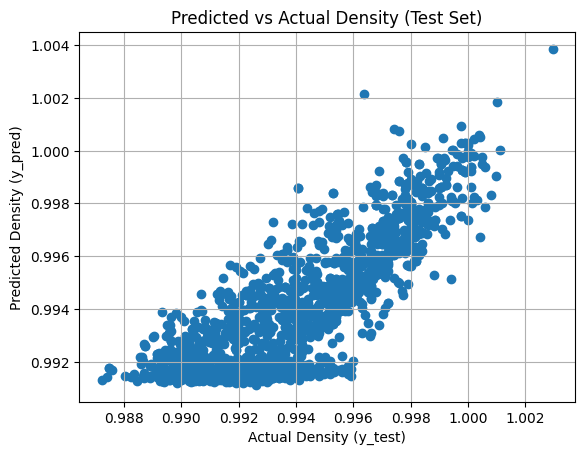

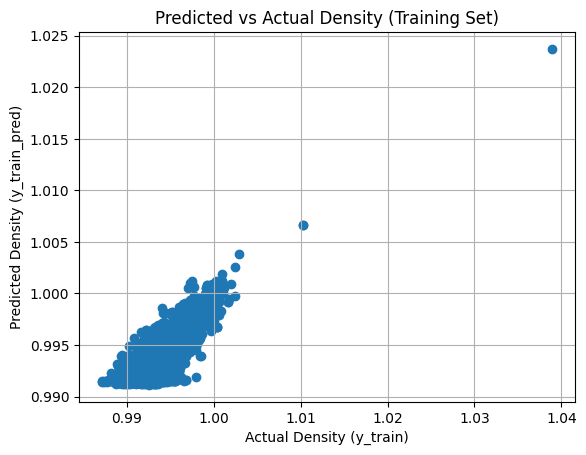

In [46]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Density (y_test)")
plt.ylabel("Predicted Density (y_pred)")
plt.title("Predicted vs Actual Density (Test Set)")
plt.grid(True)
plt.show()

y_train_pred = lr.predict(X_train)

plt.scatter(y_train, y_train_pred)
plt.xlabel("Actual Density (y_train)")
plt.ylabel("Predicted Density (y_train_pred)")
plt.title("Predicted vs Actual Density (Training Set)")
plt.grid(True)
plt.show()

Recreate the same model using multiple linear regression with all features except quality.

In [47]:
X = df.drop(['quality', 'density'], axis = 1)
y = df['density']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)
scaler = preprocessing.StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X = X_train, y = y_train)

y_pred = lr.predict(X_test)
print("R2 score: " + str(r2_score(y_test,y_pred)))


R2 score: 0.9724221101555643


Do the plot again

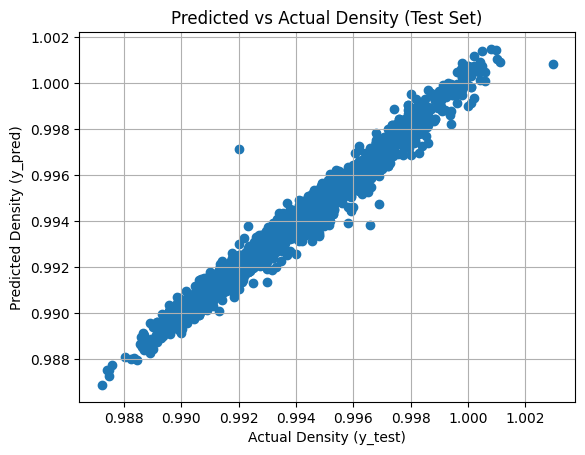

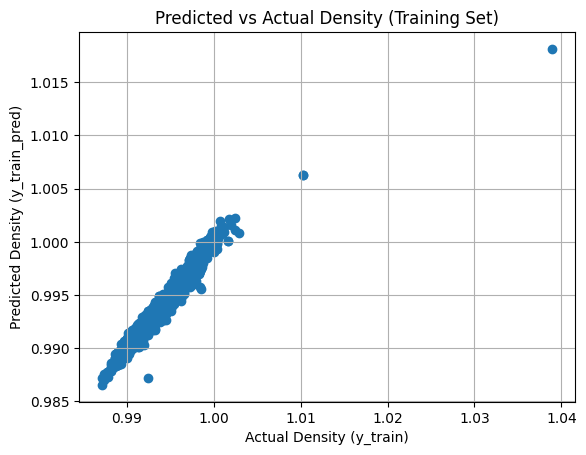

In [48]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Density (y_test)")
plt.ylabel("Predicted Density (y_pred)")
plt.title("Predicted vs Actual Density (Test Set)")
plt.grid(True)
plt.show()

y_train_pred = lr.predict(X_train)

plt.scatter(y_train, y_train_pred)
plt.xlabel("Actual Density (y_train)")
plt.ylabel("Predicted Density (y_train_pred)")
plt.title("Predicted vs Actual Density (Training Set)")
plt.grid(True)
plt.show()